# Сравнение регрессоров на California Housing

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Загрузка и подготовка данных
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Список моделей
models = {
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Lasso": Lasso(alpha=0.1),
    "Orthogonal Matching Pursuit": OrthogonalMatchingPursuit(),
    "KNN Regressor": KNeighborsRegressor()}

In [7]:
# Обучение и сбор метрик
results = []
for name, model in models.items():
    print(f'Training: {name}')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

Training: Gradient Boosting
Training: Random Forest
Training: Lasso
Training: Orthogonal Matching Pursuit
Training: KNN Regressor


In [8]:
# Таблица результатов
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
df_results_sorted

,Model,RMSE,MAE,R2 Score
0,Random Forest,0.505143,0.327425,0.805275
1,Gradient Boosting,0.542217,0.371650,0.775643
2,KNN Regressor,0.657588,0.446154,0.670010
3,Lasso,0.824396,0.622201,0.481361
4,Orthogonal Matching Pursuit,0.842090,0.629909,0.458859


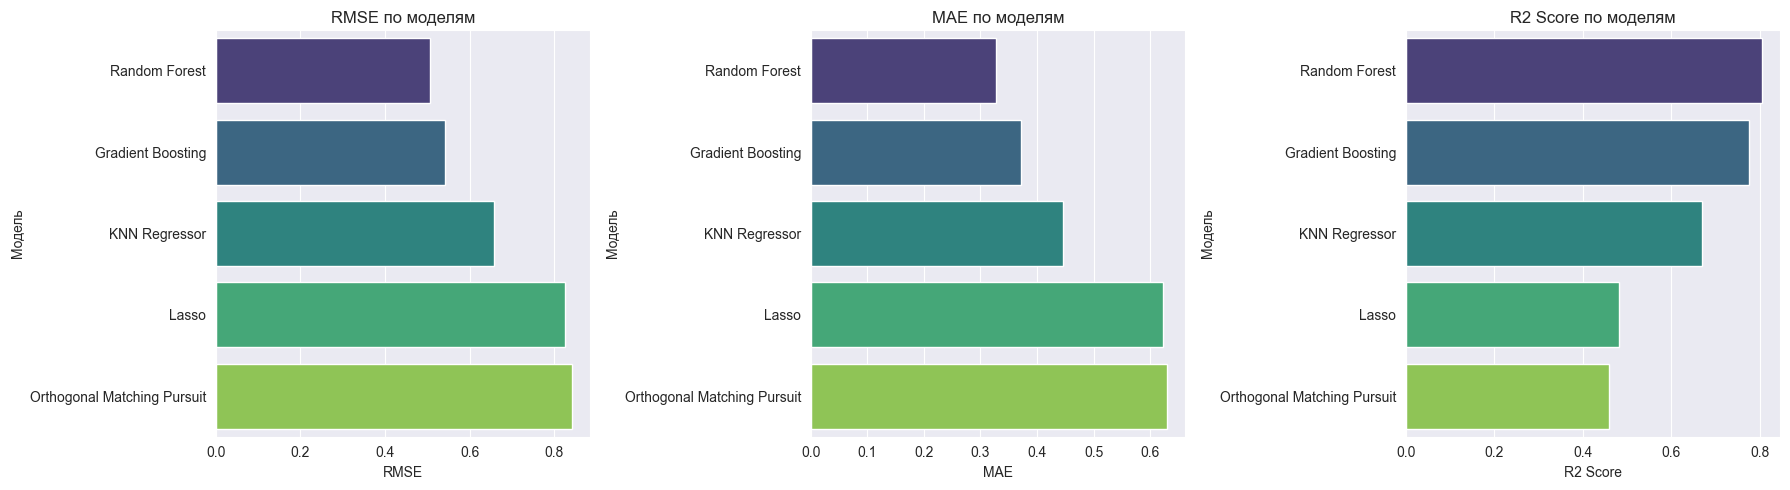

In [9]:
# Barplot по метрикам
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['RMSE', 'MAE', 'R2 Score']
for ax, metric in zip(axes, metrics):
    sns.barplot(data=df_results_sorted, x=metric, y='Model', ax=ax, palette='viridis')
    ax.set_title(f'{metric} по моделям')
    ax.set_xlabel(metric)
    ax.set_ylabel('Модель')
plt.tight_layout()
plt.show()

In [10]:
# Лучшая модель по R2 Score
best_model = df_results_sorted.iloc[0]
print(f"Лучшая модель: {best_model['Model']} с R² = {best_model['R2 Score']:.4f}")

Лучшая модель: Random Forest с R² = 0.8053
